# 01.2 — Pipeline Comparison: Old vs New Preprocessing

This notebook side-by-sides two preprocessing strategies on the same Tabula Sapiens x Tabula Muris matched-ortholog dataset, to illustrate what the new approach fixes.

**Pipeline A (old, from `01_data_preprocessing.ipynb`)**
- Uses the published `.X` matrices from `sampled_*_shared.h5ad` directly.
- Human `.X` is `log1p(normalize_total(counts))`. Mouse `.X` is the same **plus** per-gene `/std` scaling with a hard clip at 10. Scales are **mismatched** between species.
- HVG selection is run on the concatenated matrix **without** `batch_key`.
- UMAP is the inherited one from the upstream pipelines (stacked after concat, structurally broken).

**Pipeline B (new, from `01.1_hvg_investigation.ipynb`)**
- Loads raw integer counts from `adata.raw`.
- Applies identical `normalize_total(target_sum=1e4)` + `log1p` to both species — same scale.
- HVG selection with `batch_key="species"` so per-species dispersion is computed independently.
- UMAP is freshly computed on the HVG feature space.

The outputs of interest: which genes each pipeline picks as HVGs, and how the UMAP layouts differ.

In [1]:
import sys
sys.path.insert(0, "/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/speciesOT")

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
from scipy import sparse

from speciesot_helpers import (
    align_adatas_biomart_one2one,
    match_cells_by_celltype_tissue,
)

MOUSE_H5AD = "/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/data/tabula_muris/sampled_mouse_shared.h5ad"
HUMAN_H5AD = "/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/data/tabula_sapiens/sampled_human_shared.h5ad"

sc.settings.verbosity = 1

%load_ext autoreload
%autoreload 2

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Pipeline A — old approach

Uses the upstream `.X` directly (mismatched scales across species), no `batch_key` in HVG selection, inherited UMAP.

In [2]:
mouse_A = sc.read_h5ad(MOUSE_H5AD)
human_A = sc.read_h5ad(HUMAN_H5AD)

mouse_matched_A, human_matched_A = match_cells_by_celltype_tissue(
    mouse_A, human_A,
    cell_type_key="cell_type_ontology_term_id",
    tissue_key="tissue_ontology_term_id",
)

mouse_ortho_A, human_ortho_A, _ = align_adatas_biomart_one2one(
    mouse_matched_A, human_matched_A
)

combined_A = ad.concat(
    [mouse_ortho_A, human_ortho_A],
    join="inner",
    label="species", keys=["mouse", "human"],
)

sc.pp.highly_variable_genes(combined_A, n_top_genes=1000, flavor="seurat")

hvgs_A = combined_A.var_names[combined_A.var.highly_variable].tolist()
print(f"Pipeline A: {combined_A.shape}, {len(hvgs_A)} HVGs (no batch_key)")

Pipeline A: (12990, 14451), 1000 HVGs (no batch_key)


In [3]:
# Scale diagnostic — confirm the species-level mismatch that Pipeline A ignores
print("=== Pipeline A: per-species .X values (post ortholog alignment, pre concat) ===")
for name, a in [("mouse_ortho_A", mouse_ortho_A), ("human_ortho_A", human_ortho_A)]:
    X = a.X
    d = X.data if sparse.issparse(X) else X.ravel()
    sample = d[:10000]
    print(f"  {name}: min={d.min():.4f}  max={d.max():.4f}  mean={d.mean():.4f}  "
          f"unique_in_sample={len(np.unique(sample))}/{len(sample)}")

=== Pipeline A: per-species .X values (post ortholog alignment, pre concat) ===
  mouse_ortho_A: min=0.0003  max=10.0000  mean=2.1064  unique_in_sample=9961/10000
  human_ortho_A: min=0.0009  max=8.5077  mean=0.9988  unique_in_sample=139/10000


## Pipeline B — new approach

Loads raw integer counts via `adata.raw`, re-normalizes both species identically, uses `batch_key="species"` in HVG selection, and recomputes UMAP on the HVG space.

In [4]:
mouse_full = sc.read_h5ad(MOUSE_H5AD)
human_full = sc.read_h5ad(HUMAN_H5AD)

mouse_B = mouse_full.raw.to_adata()
human_B = human_full.raw.to_adata()

mouse_B.obs = mouse_full.obs.copy()
human_B.obs = human_full.obs.copy()

mouse_matched_B, human_matched_B = match_cells_by_celltype_tissue(
    mouse_B, human_B,
    cell_type_key="cell_type_ontology_term_id",
    tissue_key="tissue_ontology_term_id",
)

mouse_ortho_B, human_ortho_B, _ = align_adatas_biomart_one2one(
    mouse_matched_B, human_matched_B
)

for a in [mouse_ortho_B, human_ortho_B]:
    a.X = a.X.astype("float32")
    sc.pp.normalize_total(a, target_sum=1e4)
    sc.pp.log1p(a)

combined_B = ad.concat(
    [mouse_ortho_B, human_ortho_B],
    join="inner",
    label="species", keys=["mouse", "human"],
)

sc.pp.highly_variable_genes(
    combined_B, n_top_genes=1000, flavor="seurat", batch_key="species",
)

hvgs_B = combined_B.var_names[combined_B.var.highly_variable].tolist()
print(f"Pipeline B: {combined_B.shape}, {len(hvgs_B)} HVGs (batch_key='species')")

Pipeline B: (12990, 14451), 1000 HVGs (batch_key='species')


In [5]:
# Scale diagnostic — confirm Pipeline B's species are on matching scale
print("=== Pipeline B: per-species .X values (post ortholog alignment + renormalize) ===")
for name, a in [("mouse_ortho_B", mouse_ortho_B), ("human_ortho_B", human_ortho_B)]:
    X = a.X
    d = X.data if sparse.issparse(X) else X.ravel()
    sample = d[:10000]
    print(f"  {name}: min={d.min():.4f}  max={d.max():.4f}  mean={d.mean():.4f}  "
          f"unique_in_sample={len(np.unique(sample))}/{len(sample)}")

=== Pipeline B: per-species .X values (post ortholog alignment + renormalize) ===
  mouse_ortho_B: min=0.0003  max=8.8695  mean=1.2429  unique_in_sample=265/10000
  human_ortho_B: min=0.0013  max=8.8025  mean=1.1957  unique_in_sample=147/10000


## HVG set comparison

How much do the two HVG sets overlap? Which genes did each pipeline pick that the other didn't?

In [6]:
set_A = set(hvgs_A)
set_B = set(hvgs_B)

overlap = set_A & set_B
only_A = set_A - set_B
only_B = set_B - set_A

print(f"Pipeline A HVGs     : {len(set_A)}")
print(f"Pipeline B HVGs     : {len(set_B)}")
print(f"Shared (A ∩ B)      : {len(overlap)}  ({100*len(overlap)/max(len(set_A),1):.1f}% of A, {100*len(overlap)/max(len(set_B),1):.1f}% of B)")
print(f"Only in Pipeline A  : {len(only_A)}  (picked by A, NOT picked by B)")
print(f"Only in Pipeline B  : {len(only_B)}  (picked by B, missed by A)")

try:
    from matplotlib_venn import venn2
    plt.figure(figsize=(6, 5))
    venn2(
        [set_A, set_B],
        set_labels=("Pipeline A\n(no batch_key)", "Pipeline B\n(batch_key='species')"),
    )
    plt.title("HVG overlap between pipelines")
    plt.tight_layout()
    plt.show()
except ImportError:
    print("\n(install matplotlib-venn for a Venn diagram)")

Pipeline A HVGs     : 1000
Pipeline B HVGs     : 1000
Shared (A ∩ B)      : 74  (7.4% of A, 7.4% of B)
Only in Pipeline A  : 926  (picked by A, NOT picked by B)
Only in Pipeline B  : 926  (picked by B, missed by A)

(install matplotlib-venn for a Venn diagram)


In [7]:
# Where do canonical marker genes sit in each pipeline's ranking?
MARKERS = {
    "ENSG00000081237": "PTPRC (pan-leukocyte)",
    "ENSG00000153563": "CD8A (T cell)",
    "ENSG00000010610": "CD4 (T helper)",
    "ENSG00000177455": "CD19 (B cell)",
    "ENSG00000170458": "CD14 (monocyte)",
    "ENSG00000163631": "ALB (hepatocyte)",
    "ENSG00000107796": "ACTA2 (smooth muscle)",
    "ENSG00000118194": "TNNT2 (cardiomyocyte)",
    "ENSG00000175206": "NPPA (cardiomyocyte)",
}

rank_A = {g: i + 1 for i, g in enumerate(
    combined_A.var.sort_values("dispersions_norm", ascending=False).index
)}
rank_B = {g: i + 1 for i, g in enumerate(
    combined_B.var.sort_values(
        ["highly_variable_nbatches", "dispersions_norm"],
        ascending=[False, False],
    ).index
)}

header = f"{'Ensembl':<20} {'Symbol':<30} {'A rank':>8} {'A HVG':>7}   {'B rank':>8} {'B HVG':>7}"
print(header)
print("-" * len(header))
for eid, sym in MARKERS.items():
    in_A = eid in combined_A.var.index
    in_B = eid in combined_B.var.index
    ra = rank_A.get(eid, "-") if in_A else "absent"
    rb = rank_B.get(eid, "-") if in_B else "absent"
    ha = "yes" if eid in set_A else "no"
    hb = "yes" if eid in set_B else "no"
    print(f"{eid:<20} {sym:<30} {str(ra):>8} {ha:>7}   {str(rb):>8} {hb:>7}")

Ensembl              Symbol                           A rank   A HVG     B rank   B HVG
---------------------------------------------------------------------------------------
ENSG00000081237      PTPRC (pan-leukocyte)             14336      no       5349      no
ENSG00000153563      CD8A (T cell)                     14363      no        168     yes
ENSG00000010610      CD4 (T helper)                    13769      no       1025      no
ENSG00000177455      CD19 (B cell)                      7312      no        957     yes
ENSG00000170458      CD14 (monocyte)                    4061      no        138     yes
ENSG00000163631      ALB (hepatocyte)                    534     yes          9     yes
ENSG00000107796      ACTA2 (smooth muscle)             10441      no         14     yes
ENSG00000118194      TNNT2 (cardiomyocyte)              3852      no          5     yes
ENSG00000175206      NPPA (cardiomyocyte)               4236      no          1     yes


In [8]:
# Top 15 HVGs for each pipeline, side by side (dispersion_norm order)
top_A = combined_A.var.loc[list(set_A)].sort_values("dispersions_norm", ascending=False).head(15)
top_B = combined_B.var.loc[list(set_B)].sort_values(
    ["highly_variable_nbatches", "dispersions_norm"], ascending=[False, False]
).head(15)

print("=== Pipeline A — top 15 HVGs (by dispersions_norm) ===")
print(top_A[["means", "dispersions", "dispersions_norm"]].round(3))

print("\n=== Pipeline B — top 15 HVGs (by nbatches, then dispersions_norm) ===")
cols_B = ["means", "dispersions", "dispersions_norm",
          "highly_variable_nbatches", "highly_variable_intersection"]
cols_B = [c for c in cols_B if c in top_B.columns]
print(top_B[cols_B].round(3))

=== Pipeline A — top 15 HVGs (by dispersions_norm) ===
                 means  dispersions  dispersions_norm
ENSG00000153802  0.900        9.846             2.494
ENSG00000184221  0.935        9.841             2.492
ENSG00000180053  0.855        9.773             2.457
ENSG00000167580  0.939        9.565             2.349
ENSG00000132703  0.740        9.555             2.344
ENSG00000266265  0.683        9.452             2.291
ENSG00000135903  0.686        9.432             2.281
ENSG00000130649  0.886        9.405             2.267
ENSG00000144481  0.633        9.336             2.231
ENSG00000171189  0.644        9.306             2.215
ENSG00000205116  0.805        9.295             2.210
ENSG00000104833  0.924        9.270             2.197
ENSG00000100095  0.918        9.269             2.196
ENSG00000006071  0.695        9.256             2.190
ENSG00000107317  0.877        9.231             2.177

=== Pipeline B — top 15 HVGs (by nbatches, then dispersions_norm) ===
          

## UMAP comparison

Two different UMAPs:

- **Pipeline A**: the inherited `X_umap` that survived concat. Rows 0..n_mouse-1 are coordinates from the Tabula-Muris upstream UMAP (computed on the mouse-only matrix); rows n_mouse..end are from the Tabula-Sapiens upstream UMAP (computed independently on the human-only matrix). The two halves are in **different, unrelated UMAP spaces** stacked into one array. You will typically see the species as two disjoint islands.
- **Pipeline B**: freshly computed on the post-HVG feature space. Both species live in the same scaled-PCA-UMAP space derived from the shared HVGs. If the preprocessing worked, cells should cluster by cell type with both species interspersed.

In [9]:
# Pipeline A: use the inherited X_umap (if present after concat)
if "X_umap" in combined_A.obsm:
    print(f"Pipeline A: inherited X_umap shape = {combined_A.obsm['X_umap'].shape}")
    print("  WARNING: rows from mouse and human are in separate upstream UMAP spaces,")
    print("           stacked into one array by ad.concat. Not a joint embedding.")
else:
    print("Pipeline A: no inherited X_umap. Computing one for comparison (also flawed on mismatched .X).")
    adata_A_plot = combined_A.copy()
    sc.pp.scale(adata_A_plot, max_value=10)
    sc.tl.pca(adata_A_plot, n_comps=50, random_state=42)
    sc.pp.neighbors(adata_A_plot, n_neighbors=15, use_rep="X_pca", random_state=42)
    sc.tl.umap(adata_A_plot, min_dist=0.3, random_state=42)
    combined_A.obsm["X_umap"] = adata_A_plot.obsm["X_umap"]

Pipeline A: inherited X_umap shape = (12990, 2)
           stacked into one array by ad.concat. Not a joint embedding.


In [10]:
# Pipeline B: compute fresh UMAP on HVG feature space
adata_hvg_B = combined_B[:, combined_B.var.highly_variable].copy()

# Stash log-normalized values so we can color plots by gene expression later
adata_hvg_B.layers["log_norm"] = adata_hvg_B.X.copy()
# Also carry .raw so we can color by non-HVG genes (like PTPRC)
adata_hvg_B.raw = combined_B

# Wipe any stale embeddings
for k in list(adata_hvg_B.obsm.keys()):
    del adata_hvg_B.obsm[k]
for k in list(adata_hvg_B.obsp.keys()):
    del adata_hvg_B.obsp[k]

sc.pp.scale(adata_hvg_B, max_value=10)
sc.tl.pca(adata_hvg_B, n_comps=50, random_state=42)
sc.pp.neighbors(adata_hvg_B, n_neighbors=15, use_rep="X_pca", random_state=42)
sc.tl.umap(adata_hvg_B, min_dist=0.3, random_state=42)

print(f"Pipeline B: fresh UMAP computed on {adata_hvg_B.n_vars} HVGs")

/n/sw/Miniforge3-24.7.1-0/lib/python3.12/functools.py:907: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Pipeline B: fresh UMAP computed on 1000 HVGs


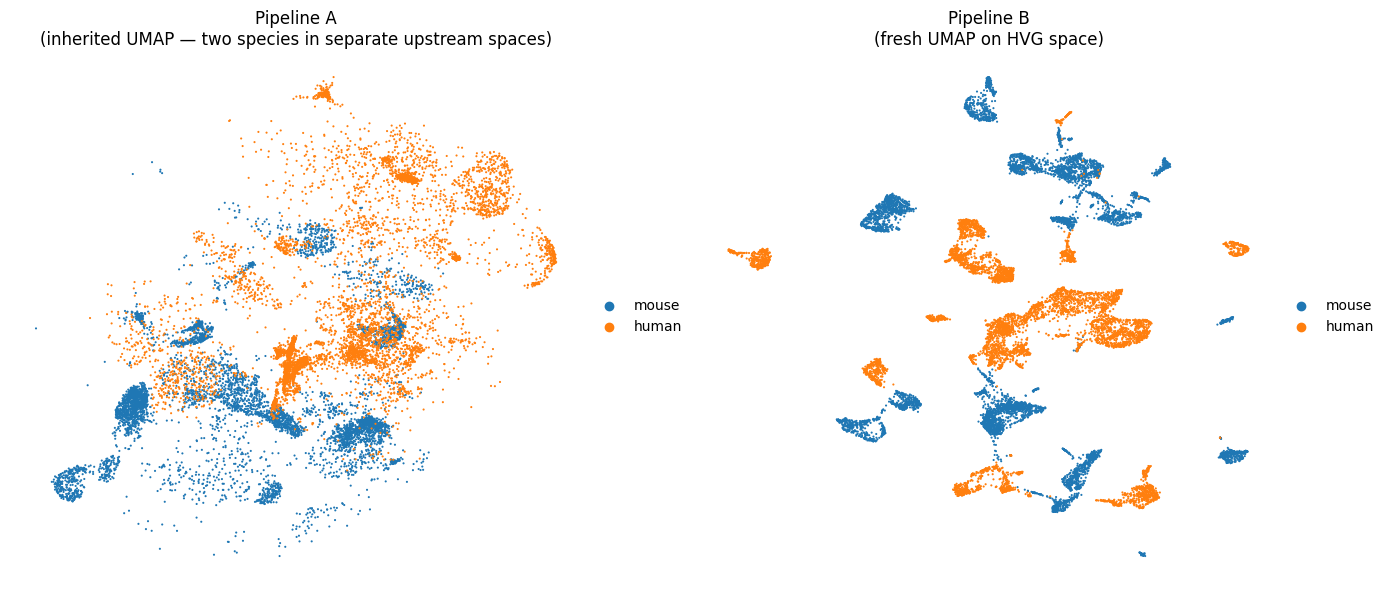

In [11]:
# Side-by-side UMAPs colored by species
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc.pl.embedding(
    combined_A, basis="X_umap", color="species",
    ax=axes[0], show=False, frameon=False,
    title="Pipeline A\n(inherited UMAP — two species in separate upstream spaces)",
)

sc.pl.embedding(
    adata_hvg_B, basis="X_umap", color="species",
    ax=axes[1], show=False, frameon=False,
    title="Pipeline B\n(fresh UMAP on HVG space)",
)

plt.tight_layout()
plt.show()

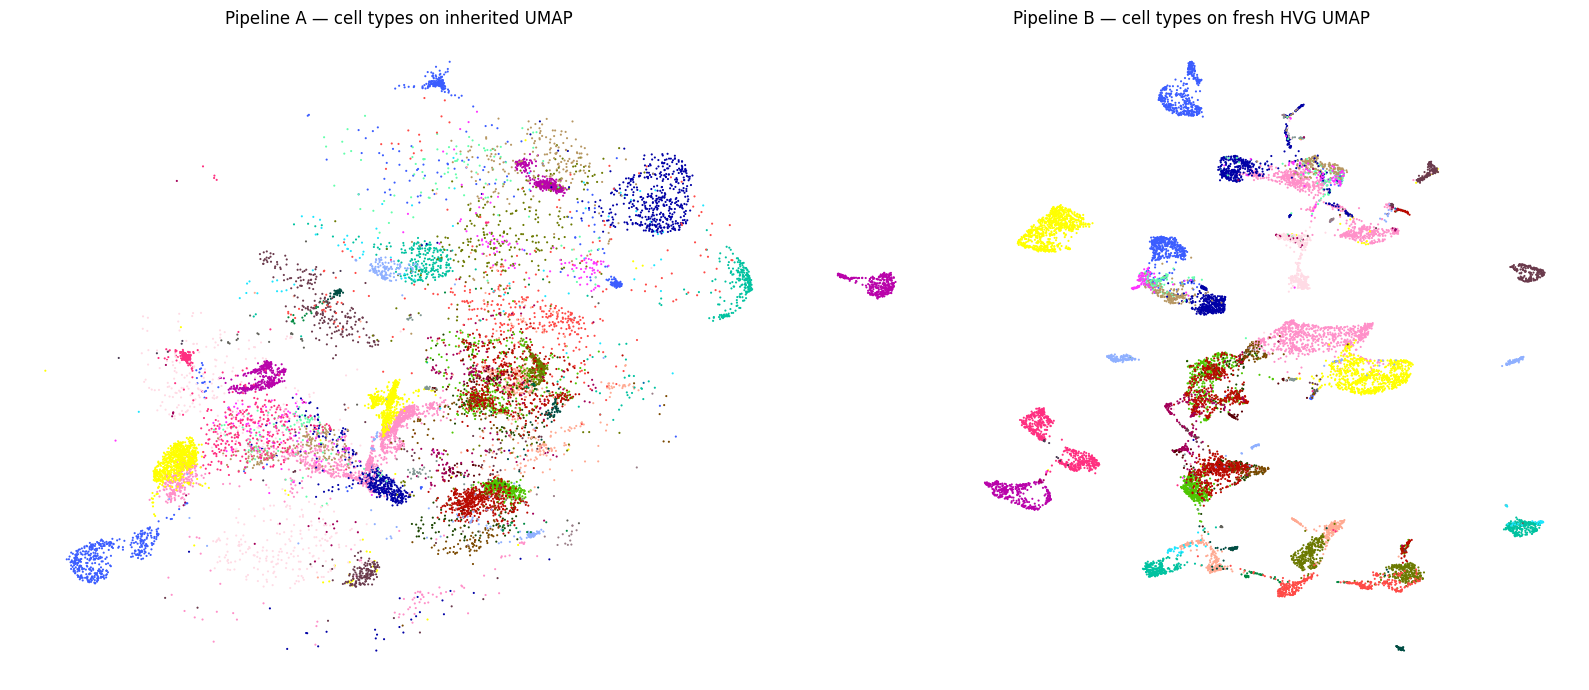

In [12]:
# Same comparison, colored by cell_type
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sc.pl.embedding(
    combined_A, basis="X_umap", color="cell_type",
    ax=axes[0], show=False, frameon=False, legend_loc=None,
    title="Pipeline A — cell types on inherited UMAP",
)

sc.pl.embedding(
    adata_hvg_B, basis="X_umap", color="cell_type",
    ax=axes[1], show=False, frameon=False, legend_loc=None,
    title="Pipeline B — cell types on fresh HVG UMAP",
)

plt.tight_layout()
plt.show()

## PTPRC deep dive

Where does PTPRC (the gene the mentor expected to find in the HVG list) actually sit in each pipeline?

In [13]:
PTPRC = "ENSG00000081237"

def ptprc_summary(name, adata, ranking, hvg_set):
    print(f"=== PTPRC in {name} ===")
    if PTPRC not in adata.var.index:
        print("  PTPRC not present in var (dropped by ortholog alignment)")
        return
    row = adata.var.loc[PTPRC]
    print(f"  highly_variable        : {row['highly_variable']}")
    if "highly_variable_nbatches" in row:
        print(f"  nbatches (of species)  : {int(row['highly_variable_nbatches'])}/2")
        print(f"  intersection?          : {row['highly_variable_intersection']}")
    print(f"  means                  : {row['means']:.4f}")
    print(f"  dispersions            : {row['dispersions']:.4f}")
    print(f"  dispersions_norm       : {row['dispersions_norm']:.4f}")
    print(f"  rank                   : {ranking.get(PTPRC, 'N/A')} / {len(ranking)}")
    print(f"  in top-1000 HVGs?      : {PTPRC in hvg_set}")

ptprc_summary("Pipeline A", combined_A, rank_A, set_A)
print()
ptprc_summary("Pipeline B", combined_B, rank_B, set_B)

=== PTPRC in Pipeline A ===
  highly_variable        : False
  means                  : 1.9936
  dispersions            : 2.9107
  dispersions_norm       : -4.1642
  rank                   : 14336 / 14451
  in top-1000 HVGs?      : False

=== PTPRC in Pipeline B ===
  highly_variable        : False
  nbatches (of species)  : 0/2
  intersection?          : False
  means                  : 2.0673
  dispersions            : 2.8406
  dispersions_norm       : 0.0887
  rank                   : 5349 / 14451
  in top-1000 HVGs?      : False


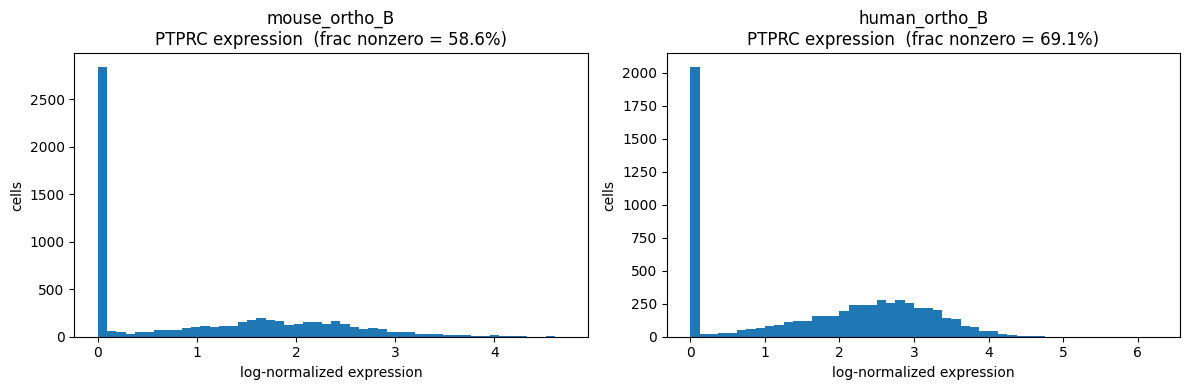

In [14]:
# PTPRC's per-species distribution: is it "bimodal" (cell-type-discriminating)
# or "uniformly on" (pan-leukocyte)?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, a) in zip(axes, [("mouse_ortho_B", mouse_ortho_B),
                                 ("human_ortho_B", human_ortho_B)]):
    if PTPRC not in a.var_names:
        ax.set_title(f"{name}: PTPRC absent")
        continue
    idx = a.var_names.get_loc(PTPRC)
    vals = a.X[:, idx]
    vals = vals.toarray().ravel() if sparse.issparse(vals) else np.asarray(vals).ravel()
    ax.hist(vals, bins=50)
    frac_nz = (vals > 0).mean() * 100
    ax.set_title(f"{name}\nPTPRC expression  (frac nonzero = {frac_nz:.1f}%)")
    ax.set_xlabel("log-normalized expression")
    ax.set_ylabel("cells")

plt.tight_layout()
plt.show()

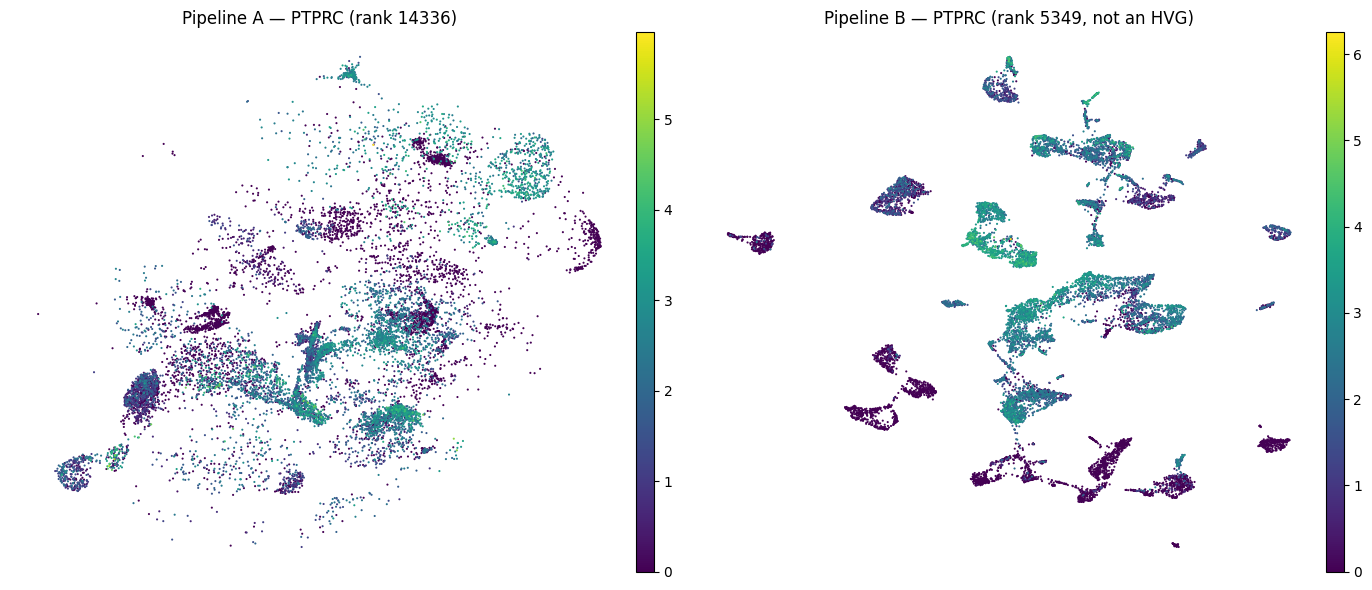

In [15]:
# PTPRC expression overlaid on each UMAP
# Pipeline A: color by upstream PTPRC values in combined_A.X
# Pipeline B: PTPRC isn't in adata_hvg_B, but we set .raw = combined_B so use_raw=True works
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

if PTPRC in combined_A.var.index:
    sc.pl.embedding(
        combined_A, basis="X_umap", color=PTPRC,
        ax=axes[0], show=False, frameon=False, use_raw=False,
        title=f"Pipeline A — PTPRC (rank {rank_A.get(PTPRC, 'N/A')})",
    )
else:
    axes[0].set_title("Pipeline A — PTPRC absent from var")

if PTPRC in combined_B.var.index:
    sc.pl.embedding(
        adata_hvg_B, basis="X_umap", color=PTPRC,
        ax=axes[1], show=False, frameon=False, use_raw=True,
        title=f"Pipeline B — PTPRC (rank {rank_B.get(PTPRC, 'N/A')}, not an HVG)",
    )
else:
    axes[1].set_title("Pipeline B — PTPRC absent from var")

plt.tight_layout()
plt.show()

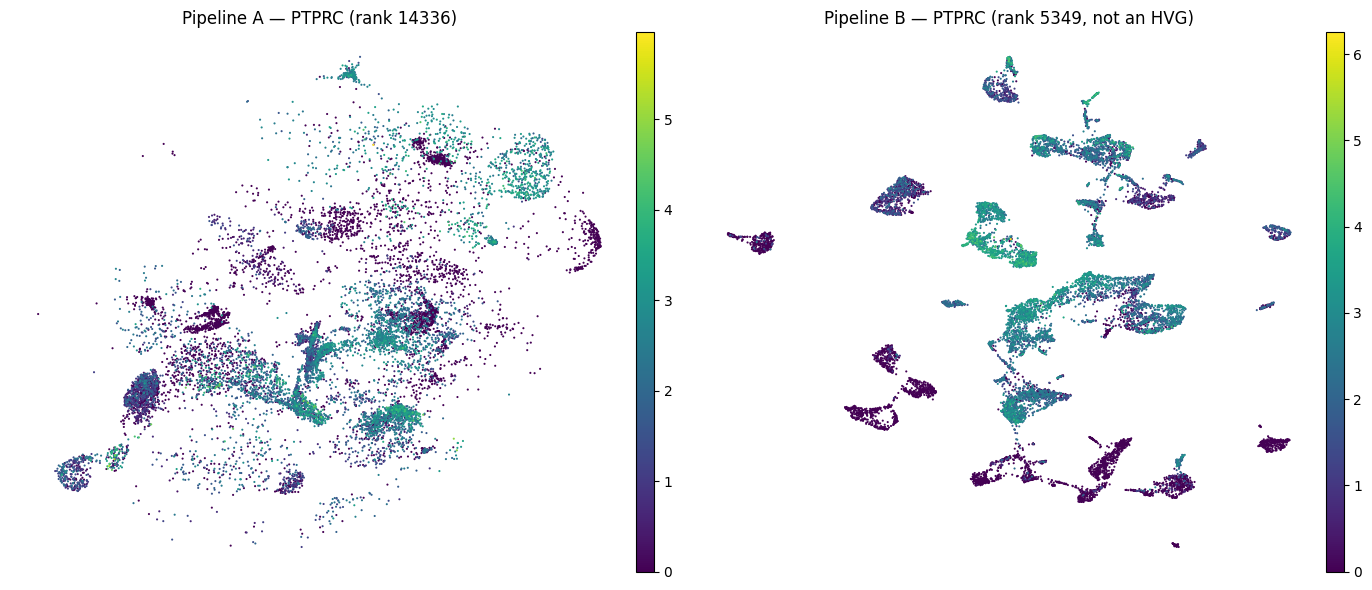

In [16]:
# PTPRC expression overlaid on each UMAP
# Pipeline A: color by upstream PTPRC values in combined_A.X
# Pipeline B: PTPRC isn't in adata_hvg_B, but we set .raw = combined_B so use_raw=True works
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

if PTPRC in combined_A.var.index:
    sc.pl.embedding(
        combined_A, basis="X_umap", color=PTPRC,
        ax=axes[0], show=False, frameon=False, use_raw=False,
        title=f"Pipeline A — PTPRC (rank {rank_A.get(PTPRC, 'N/A')})",
    )
else:
    axes[0].set_title("Pipeline A — PTPRC absent from var")

if PTPRC in combined_B.var.index:
    sc.pl.embedding(
        adata_hvg_B, basis="X_umap", color=PTPRC,
        ax=axes[1], show=False, frameon=False, use_raw=True,
        title=f"Pipeline B — PTPRC (rank {rank_B.get(PTPRC, 'N/A')}, not an HVG)",
    )
else:
    axes[1].set_title("Pipeline B — PTPRC absent from var")

plt.tight_layout()
plt.show()

Top HVG in Pipeline B: ENSG00000175206  NPPA (cardiomyocyte)
  rank (B): 1
  means=0.592, dispersions_norm=6.808, nbatches=2

PTPRC for contrast: ENSG00000081237  (pan-leukocyte)
  rank (B): 5349
  means=2.067, dispersions_norm=0.089, nbatches=0


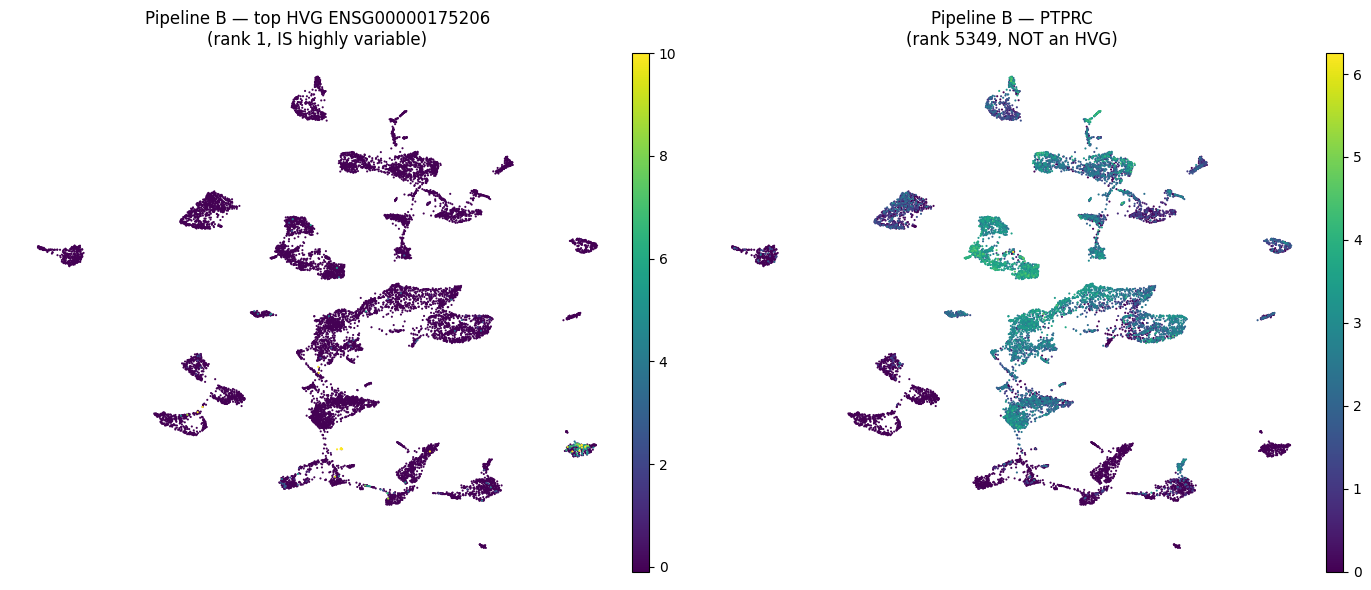

In [17]:
# HVG vs PTPRC on Pipeline B's UMAP
# Contrasts a gene that IS highly variable (top HVG by nbatches, dispersions_norm)
# with PTPRC (not an HVG: pan-leukocyte, uniformly on, low dispersion_norm).
# Both plotted on the same Pipeline-B UMAP for a direct visual comparison.

top_hvg_B = combined_B.var.loc[list(set_B)].sort_values(
    ["highly_variable_nbatches", "dispersions_norm"], ascending=[False, False]
).index[0]
top_hvg_symbol = MARKERS.get(top_hvg_B, "(no symbol in MARKERS)")
top_hvg_rank = rank_B.get(top_hvg_B, "N/A")

print(f"Top HVG in Pipeline B: {top_hvg_B}  {top_hvg_symbol}")
print(f"  rank (B): {top_hvg_rank}")
print(f"  means={combined_B.var.loc[top_hvg_B, 'means']:.3f}, "
      f"dispersions_norm={combined_B.var.loc[top_hvg_B, 'dispersions_norm']:.3f}, "
      f"nbatches={int(combined_B.var.loc[top_hvg_B, 'highly_variable_nbatches'])}")
print()
print(f"PTPRC for contrast: {PTPRC}  (pan-leukocyte)")
print(f"  rank (B): {rank_B.get(PTPRC, 'N/A')}")
print(f"  means={combined_B.var.loc[PTPRC, 'means']:.3f}, "
      f"dispersions_norm={combined_B.var.loc[PTPRC, 'dispersions_norm']:.3f}, "
      f"nbatches={int(combined_B.var.loc[PTPRC, 'highly_variable_nbatches'])}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: top HVG. It's in adata_hvg_B's own var, so use_raw=False pulls from
# the scaled HVG matrix (what PCA/UMAP actually saw).
sc.pl.embedding(
    adata_hvg_B, basis="X_umap", color=top_hvg_B,
    ax=axes[0], show=False, frameon=False, use_raw=False,
    title=f"Pipeline B — top HVG {top_hvg_B}\n(rank {top_hvg_rank}, IS highly variable)",
)

# Right: PTPRC. Not in adata_hvg_B.var but present in adata_hvg_B.raw,
# so use_raw=True pulls from the log-normalized full gene matrix.
sc.pl.embedding(
    adata_hvg_B, basis="X_umap", color=PTPRC,
    ax=axes[1], show=False, frameon=False, use_raw=True,
    title=f"Pipeline B — PTPRC\n(rank {rank_B.get(PTPRC, 'N/A')}, NOT an HVG)",
)

plt.tight_layout()
plt.show()

## Summary

| Property | Pipeline A (old) | Pipeline B (new) |
|---|---|---|
| Input `.X` | Mismatched across species (human `log1p`; mouse `log1p + /std + clip`) | Identical scales (both `log1p(normalize_total(raw, 1e4))`) |
| `batch_key` in HVG | No | `"species"` |
| Species-baseline variance | Counted as "variance" — inflates HVG dispersion artifactually | Attributed to species; doesn't register inside per-species bins |
| HVG ranking | by `dispersions_norm` | by `highly_variable_nbatches`, then `dispersions_norm` |
| UMAP | Inherited from upstream (two independent embeddings stacked) | Freshly computed on HVG feature space |
| PTPRC outcome | May appear due to cross-species scale confound | Correctly excluded: too uniformly expressed in the immune-dominated matched dataset |

### Interpretation

Pipeline A's HVGs are contaminated with **species-discriminating genes** — genes that "vary" only because the two species' `.X` matrices sit on different scales. Pipeline B's HVGs reflect **genuine biological variation** conserved across species.

PTPRC (the canonical pan-leukocyte marker) does not appear in either pipeline's top-1000 HVGs once the cross-species scale mismatch is removed. This is not a bug — the matched dataset is dominated by immune cells (~60-69% of cells express PTPRC), so PTPRC is "uniformly on" rather than a cell-type discriminator. Subtype markers (CD8A, CD19, CD14, NK markers) correctly take its place.

### Files to reference

- Full technical detail: `research_log_2026-04-20.txt` at project root.
- Helper functions: `speciesOT/speciesot_helpers.py` — `align_adatas_biomart_one2one`, `match_cells_by_celltype_tissue`.
- Prior investigation notebooks: `01_data_preprocessing.ipynb` (pipeline A), `01.1_hvg_investigation.ipynb` (pipeline B).